# Use ResNet for classification Chapter 9 Workshop 5

## Load module

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.models import load_model

## Load model

In [2]:
model = ResNet50(weights='imagenet')   # Load the VGG16 model with ImageNet weights
# model = VGG16()                   # Load the VGG16 model with ImageNet weights default weights = imagenet

# model_path = './model/vgg16_model.h5'   # Path to the saved model
# model = load_model(model_path)          # Load the model from the specified path

model.summary()  # Print the model summary

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 81s 1us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Save model

In [3]:
model.save('./model/resnet50_model.h5')  # Save the model to a file

## Test prediction

### Load image

In [19]:
image_path = r'D:\Programming_File\Tensorflow_Files\datasets\test_set\cat9002.jpg'  # Path to the input image

img = load_img(image_path, target_size=(224, 224))  # Load the image and resize it to the input size of the model
img_arr = img_to_array(img)  # Convert the image to a NumPy array

### Visualize image

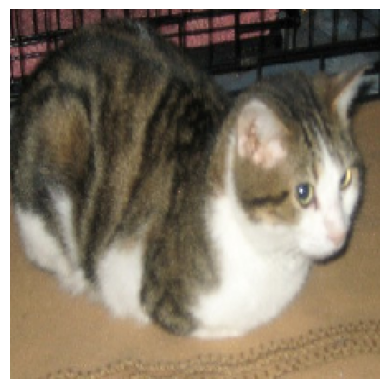

In [20]:
img_show = img_arr/255.0  # Preprocess the image for the ResNet50 model
plt.imshow(img_show)  # Display the image
plt.axis('off')  # Hide the axis
plt.show()  # Show the image

### Prediction

In [21]:
# Expand the dimensions of the image array to match the input shape of the model
img_arr = np.expand_dims(img_arr, axis=0)  # Add a batch dimension to the image array
img_arr = preprocess_input(img_arr)  # Preprocess the image for the VGG16 model
result = model.predict(img_arr)  # Make predictions using the model

# print(result)  # Print the raw prediction result
# Decode the predictions to get the class labels and probabilities
decoded_result = decode_predictions(result, top=5)[0]  # Decode the predictions
# Print the top 5 predicted classes and their probabilities
for i, (imagenet_id, label, score) in enumerate(decoded_result):
    print(f"{i + 1}: {label} ({score:.2f})")  # Print the class label and probability
# Print the predicted class label
predicted_class = decoded_result[0][1]  # Get the predicted class label
print(f"Predicted class: {predicted_class}")  # Print the predicted class label
# Print the predicted class index
predicted_class_index = decoded_result[0][0]  # Get the predicted class index
print(f"Predicted class index: {predicted_class_index}")  # Print the predicted class index
# Print the predicted class probability
predicted_class_probability = decoded_result[0][2]  # Get the predicted class probability
print(f"Predicted class probability: {predicted_class_probability}")  # Print the predicted class probability
# Print the shape of the prediction result
print(f"Shape of prediction result: {result.shape}")  # Print the shape of the prediction result
# Print the shape of the image array
print(f"Shape of image array: {img_arr.shape}")  # Print the shape of the image array

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1: tabby (0.47)
2: tiger_cat (0.20)
3: Egyptian_cat (0.09)
4: space_heater (0.04)
5: Angora (0.02)
Predicted class: tabby
Predicted class index: n02123045
Predicted class probability: 0.47397786378860474
Shape of prediction result: (1, 1000)
Shape of image array: (1, 224, 224, 3)
